In [210]:
import pandas as pd
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator,MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt
import networkx as nx

data = pd.read_csv('test_regresyon_final.csv', encoding='utf-8')


data_renamed = data.rename(columns={
    "RÜZGAR HIZI (KM/SAAT)": "Rüzgar Hızı",
    "Sıcaklık (°C)": "Sıcaklık",
    "Nem Seviyesi (%)": "Nem Seviyesi",
    "Yağmur Olasılığı (%)": "Yağmur Olasılığı",
    "Uçuş Başarısı (%)": "Uçuş Başarısı"
})

print(data_renamed)



     GÜN  Rüzgar Hızı  Sıcaklık  Nem Seviyesi  Yağmur Olasılığı  \
0      2    15.000000      22.0     21.000000              27.0   
1      3    11.000000      21.0     89.000000              43.0   
2      4     6.000000       6.0     59.615385              53.0   
3      6    25.000000      12.0     61.000000              72.0   
4     10    17.000000      27.0     71.000000              28.0   
..   ...          ...       ...           ...               ...   
134  193     7.000000      22.0     54.000000              26.0   
135  194    58.000000      38.0     10.000000              29.0   
136  195    33.000000       0.0     62.000000              68.0   
137  197    24.169355      21.0     66.000000              21.0   
138  198    51.000000      28.0     60.000000              20.0   

     Uçuş Başarısı  Tahmin Edilen Uçuş Başarısı (%)  
0        79.875000                        87.331576  
1        71.625000                        81.708985  
2        97.600000               

In [211]:
# Sürekli hava durumu değişkenlerini kesikli hale getirme (Düşük, Orta,Yüksek)
data_renamed['Rüzgar Hızı'] = pd.cut(data_renamed['Rüzgar Hızı'], bins=3, labels=False)
data_renamed['Sıcaklık'] = pd.cut(data_renamed['Sıcaklık'], bins=3, labels=False)
data_renamed['Nem Seviyesi'] = pd.cut(data_renamed['Nem Seviyesi'], bins=3, labels=False)
data_renamed['Yağmur Olasılığı'] = pd.cut(data_renamed['Yağmur Olasılığı'], bins=3, labels=False)
# Uçuş başarısı 'başarılı' ve 'başarısız' olarak ayrıldı
data_renamed['Uçuş Başarısı'] = pd.cut(data_renamed['Uçuş Başarısı'], bins=2, labels=False)

# Bayesian Network tanımı
model = BayesianNetwork([
    ("Rüzgar Hızı", "Uçuş Başarısı"),
    ("Sıcaklık", "Uçuş Başarısı"),
    ("Nem Seviyesi", "Uçuş Başarısı"),
    ("Yağmur Olasılığı", "Uçuş Başarısı")
])

# Parametre öğrenme, MaximumLikelihoodEstimator parametreleri öğrenir
model.fit(data_renamed, estimator=MaximumLikelihoodEstimator)


#VariableEliminaton algoritması ile koşullu olasılıkları hesaplama(Çıkarım yapma)
inference = VariableElimination(model)

# Rüzgar hızına göre olasılık dağılımı
# Olasılık dağılımını hesaplama
query_result = inference.query(variables=["Uçuş Başarısı"], evidence={"Rüzgar Hızı": 1})
print(query_result)

+------------------+----------------------+
| Uçuş Başarısı    |   phi(Uçuş Başarısı) |
+==================+======================+
| Uçuş Başarısı(0) |               0.1257 |
+------------------+----------------------+
| Uçuş Başarısı(1) |               0.8743 |
+------------------+----------------------+


In [212]:
# Yağmur olasılığına göre dağılımı
query_result = inference.query(variables=["Uçuş Başarısı"], evidence={"Yağmur Olasılığı": 1})
print(query_result)


+------------------+----------------------+
| Uçuş Başarısı    |   phi(Uçuş Başarısı) |
+==================+======================+
| Uçuş Başarısı(0) |               0.3048 |
+------------------+----------------------+
| Uçuş Başarısı(1) |               0.6952 |
+------------------+----------------------+


In [213]:
# Sıcaklığa göre olasılık dağılımı
query_result = inference.query(variables=["Uçuş Başarısı"], evidence={"Sıcaklık": 1})
print(query_result)


+------------------+----------------------+
| Uçuş Başarısı    |   phi(Uçuş Başarısı) |
+==================+======================+
| Uçuş Başarısı(0) |               0.1300 |
+------------------+----------------------+
| Uçuş Başarısı(1) |               0.8700 |
+------------------+----------------------+


In [214]:
# Neme göre olaslık dağılımı
query_result = inference.query(variables=["Uçuş Başarısı"], evidence={"Nem Seviyesi":1})


print(query_result)

+------------------+----------------------+
| Uçuş Başarısı    |   phi(Uçuş Başarısı) |
+==================+======================+
| Uçuş Başarısı(0) |               0.0721 |
+------------------+----------------------+
| Uçuş Başarısı(1) |               0.9279 |
+------------------+----------------------+


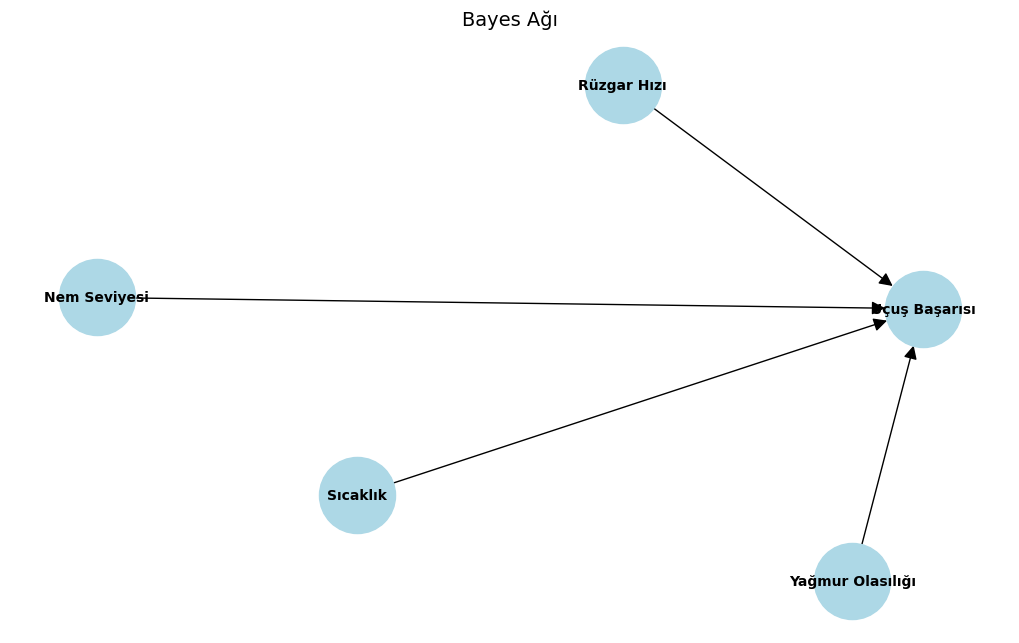

In [215]:
graph = nx.DiGraph(model.edges())
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Bayes Ağı", fontsize=14)
plt.show()